# Importing Libraries and Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib


# Defining the file path
file_path = r"/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Telecom Customer Churn prediction/Data & Resources/Data/vw_ChurnData.xlsx"


#Defining the sheet name from where are going to fetch the data
sheet_name = "vw_ChurnData"


# Reading the data from the excel sheet by converting it into the PD Dataframe
data = pd.read_excel(file_path, sheet_name = sheet_name)


data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  1000 non-null   object 
 1   Gender                       1000 non-null   object 
 2   Age                          1000 non-null   int64  
 3   Married                      1000 non-null   object 
 4   State                        1000 non-null   object 
 5   Number_of_Referrals          1000 non-null   int64  
 6   Tenure_in_Months             1000 non-null   int64  
 7   Value_Deal                   472 non-null    object 
 8   Phone_Service                1000 non-null   object 
 9   Multiple_Lines               899 non-null    object 
 10  Internet_Service             1000 non-null   object 
 11  Internet_Type                797 non-null    object 
 12  Online_Security              797 non-null    object 
 13  Online_Backup      

In [4]:
data.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,46.961000,7.251000,17.088000,65.826100,2511.344850,1.982860,6.440000,816.44496,3332.246950
std,16.613533,4.638482,10.619559,31.550722,2320.360648,7.787997,24.902742,873.04648,2909.749731
min,18.000000,0.000000,1.000000,-10.000000,19.300000,0.000000,0.000000,0.00000,24.210000
25%,33.000000,3.000000,8.000000,35.375000,555.237500,0.000000,0.000000,105.14750,836.325000
50%,46.000000,7.000000,16.000000,73.625000,1557.175000,0.000000,0.000000,450.08000,2494.090000
75%,60.000000,11.000000,26.000000,92.162500,4170.725000,0.000000,0.000000,1349.64000,5404.212500
max,83.000000,15.000000,36.000000,116.850000,8543.250000,49.790000,150.000000,3482.64000,11979.340000


# Data Preprocessing

In [6]:
# Drop columns that won't be used for prediction

data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

 

# List of columns to be label encoded

columns_to_encode = [

    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',

    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',

    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',

    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',

    'Payment_Method'

]

 

# Encode categorical variables except the target variable

label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(data[column])

 

# Manually encode the target variable 'Customer_Status'

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

 

# Split data into features and target

X = data.drop('Customer_Status', axis=1)

y = data['Customer_Status']

 

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest Model

In [14]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

 

# Train the model

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Evaluaing The Model

In [16]:
# Evaluating Model

# Make predictions

y_pred = rf_model.predict(X_test)

 

# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

 

# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

Confusion Matrix:
[[135   6]
 [ 25  34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       141
           1       0.85      0.58      0.69        59

    accuracy                           0.84       200
   macro avg       0.85      0.77      0.79       200
weighted avg       0.85      0.84      0.84       200



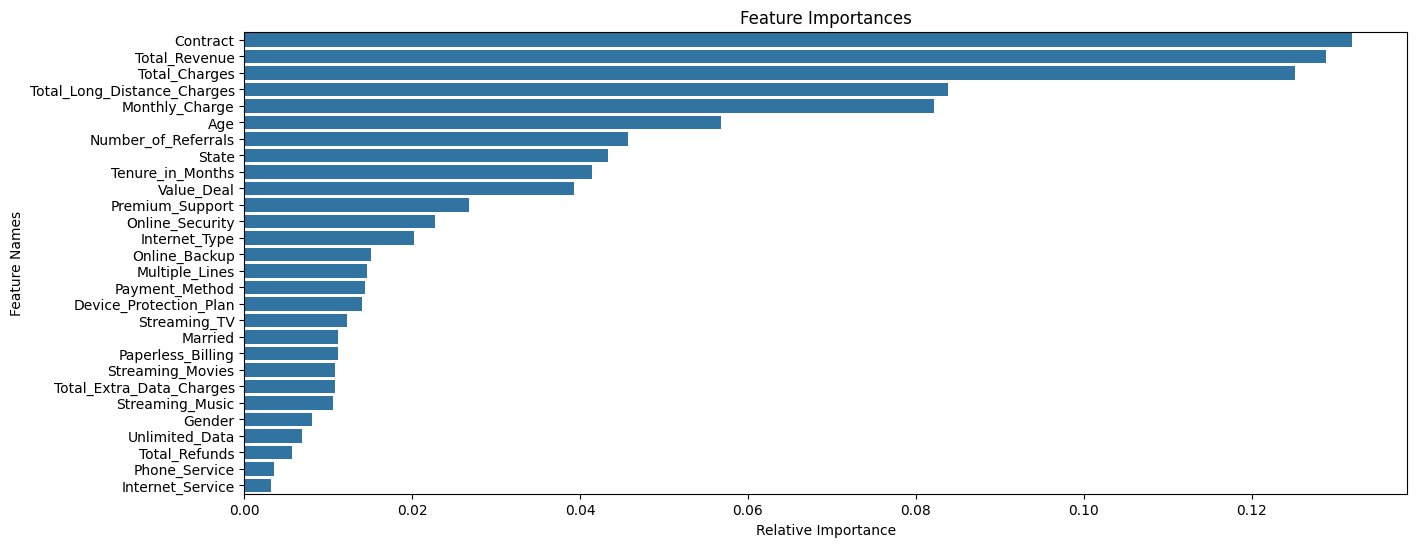

In [18]:
# Visualization

# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()


# Using Model for prediction on New data (vw_Joindata)

In [20]:
# Loading the Dataset

# Define the path to the Joiner Data Excel file
file_path = r"/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Telecom Customer Churn prediction/Data & Resources/Data/vw_JoinData-2.xlsx"

 

# Define the sheet name to read data from

sheet_name = 'vw_JoinData'

 

# Read the data from the specified sheet into a pandas DataFrame

new_data = pd.read_excel(file_path, sheet_name=sheet_name)

 

# Display the first few rows of the fetched data

print(new_data.head())

 

# Retain the original DataFrame to preserve unencoded columns

original_data = new_data.copy()

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   93520-GUJ  Female   67      No         Gujarat                   13   
1   57256-BIH  Female   18      No           Bihar                    9   
2   72357-MAD  Female   53      No  Madhya Pradesh                   14   
3   66612-KAR  Female   58     Yes       Karnataka                   11   
4   22119-WES    Male   31     Yes     West Bengal                    5   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                19     Deal 5           Yes            Yes  ...   
1                 7        NaN           Yes             No  ...   
2                12     Deal 5           Yes             No  ...   
3                18        NaN           Yes             No  ...   
4                 5        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal          72.10          72.1           0.0   
1      Cre

In [22]:
new_data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,Bank Withdrawal,72.10,72.1,0.0,0,7.77,79.87,Joined,NaN,NaN
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,Credit Card,19.85,57.2,0.0,0,9.36,66.56,Joined,NaN,NaN
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,Credit Card,44.30,44.3,0.0,0,42.95,87.25,Joined,NaN,NaN
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,Credit Card,19.95,58.0,0.0,0,8.07,66.07,Joined,NaN,NaN
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,Credit Card,20.05,33.7,0.0,0,3.62,37.32,Joined,NaN,NaN


In [24]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  411 non-null    object 
 1   Gender                       411 non-null    object 
 2   Age                          411 non-null    int64  
 3   Married                      411 non-null    object 
 4   State                        411 non-null    object 
 5   Number_of_Referrals          411 non-null    int64  
 6   Tenure_in_Months             411 non-null    int64  
 7   Value_Deal                   160 non-null    object 
 8   Phone_Service                411 non-null    object 
 9   Multiple_Lines               379 non-null    object 
 10  Internet_Service             411 non-null    object 
 11  Internet_Type                244 non-null    object 
 12  Online_Security              244 non-null    object 
 13  Online_Backup       

In [26]:
new_data.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Churn_Category,Churn_Reason
count,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,0.0,0.0
mean,43.878345,7.253041,16.586375,42.683455,79.104380,0.263625,2.384428,38.681290,119.906472,NaN,NaN
std,14.797488,4.611143,10.314764,24.789735,68.014455,2.888660,9.533415,33.837459,89.982056,NaN,NaN
min,18.000000,0.000000,1.000000,-8.000000,18.800000,0.000000,0.000000,0.000000,21.360000,NaN,NaN
25%,32.000000,3.000000,8.000000,20.150000,25.075000,0.000000,0.000000,12.210000,55.485000,NaN,NaN
50%,43.000000,7.000000,15.000000,43.950000,50.600000,0.000000,0.000000,30.730000,90.980000,NaN,NaN
75%,55.000000,11.000000,25.000000,63.500000,107.950000,0.000000,0.000000,52.140000,167.655000,NaN,NaN
max,85.000000,15.000000,36.000000,107.950000,335.750000,38.840000,70.000000,148.890000,456.100000,NaN,NaN


In [28]:
# Data Preprocessing

# Retain the Customer_ID column

customer_ids = new_data['Customer_ID']

 

# Drop columns that won't be used for prediction in the encoded DataFrame

new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

In [30]:
# Encoding categorical variables using the saved label encoders

for column in new_data.select_dtypes(include=['object']).columns:

    new_data[column] = label_encoders[column].transform(new_data[column])

In [32]:
# Making predictions using the Random Forest model

new_predictions = rf_model.predict(new_data)

In [34]:
# Add predictions to the original DataFrame

original_data['Customer_Status_Predicted'] = new_predictions

 

# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

In [42]:
# Save the results

original_data.to_csv("/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Telecom Customer Churn prediction/Data & Resources/Data/Predictions.csv", index=False)